In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving german_credit_data_updated.csv to german_credit_data_updated.csv


In [ ]:
df = pd.read_csv("german_credit_data_updated.csv")

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,2,49,male,1,own,little,NaN,2096,12,education,1
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,4,53,male,2,free,little,little,4870,24,car,2


In [ ]:
print("Shape :", df.shape)

print("\nColumns\n")
print(df.columns)

print("\nInfo\n")
df.info()

Shape : (954, 11)

Columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose',
       'Credit Risk'],
      dtype='object')

Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        954 non-null    int64 
 1   Age               954 non-null    int64 
 2   Sex               954 non-null    object
 3   Job               954 non-null    int64 
 4   Housing           954 non-null    object
 5   Saving accounts   779 non-null    object
 6   Checking account  576 non-null    object
 7   Credit amount     954 non-null    int64 
 8   Duration          954 non-null    int64 
 9   Purpose           954 non-null    object
 10  Credit Risk       954 non-null    int64 
dtypes: int64(6), object(5)
memory usage: 82.1+ KB


In [ ]:
df.describe(include="all")

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
count,954.000000,954.000000,954,954.000000,954,779,576,954.000000,954.000000,954,954.000000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,NaN
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,NaN
freq,NaN,NaN,656,NaN,680,576,261,NaN,NaN,322,NaN
mean,476.500000,35.501048,NaN,1.909853,NaN,NaN,NaN,3279.112159,20.780922,NaN,1.302935
std,275.540378,11.379668,NaN,0.649681,NaN,NaN,NaN,2853.315158,12.046483,NaN,0.459768
min,0.000000,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,1.000000
25%,238.250000,27.000000,NaN,2.000000,NaN,NaN,NaN,1360.250000,12.000000,NaN,1.000000
50%,476.500000,33.000000,NaN,2.000000,NaN,NaN,NaN,2302.500000,18.000000,NaN,1.000000
75%,714.750000,42.000000,NaN,2.000000,NaN,NaN,NaN,3975.250000,24.000000,NaN,2.000000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,175
Checking account,378
Credit amount,0
Duration,0
Purpose,0


In [ ]:
df["Saving accounts"] = df["Saving accounts"].fillna("Unknown")

df["Checking account"] = df["Checking account"].fillna("Unknown")

df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0


In [ ]:
df.drop("Unnamed: 0", axis=1, inplace=True)

df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,67,male,2,own,Unknown,little,1169,6,radio/TV,1
1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,49,male,1,own,little,Unknown,2096,12,education,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,53,male,2,free,little,little,4870,24,car,2


In [ ]:
encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,67,1,2,1,0,1,1169,6,5,1
1,22,0,2,1,1,2,5951,48,5,2
2,49,1,1,1,1,0,2096,12,3,1
3,45,1,2,0,1,1,7882,42,4,1
4,53,1,2,0,1,1,4870,24,1,2


In [ ]:
df["Monthly_Credit_Burden"] = (
    df["Credit amount"] / df["Duration"]
)

df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk,Monthly_Credit_Burden
0,67,1,2,1,0,1,1169,6,5,1,194.833333
1,22,0,2,1,1,2,5951,48,5,2,123.979167
2,49,1,1,1,1,0,2096,12,3,1,174.666667
3,45,1,2,0,1,1,7882,42,4,1,187.666667
4,53,1,2,0,1,1,4870,24,1,2,202.916667


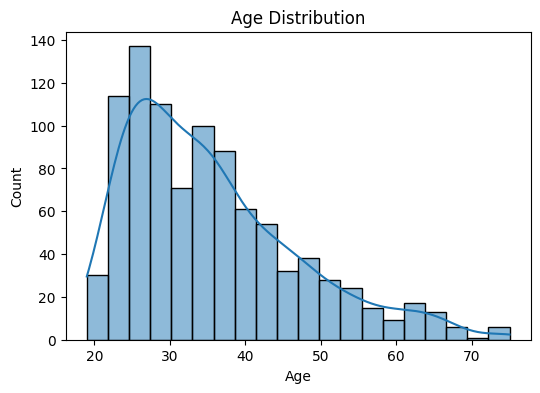

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

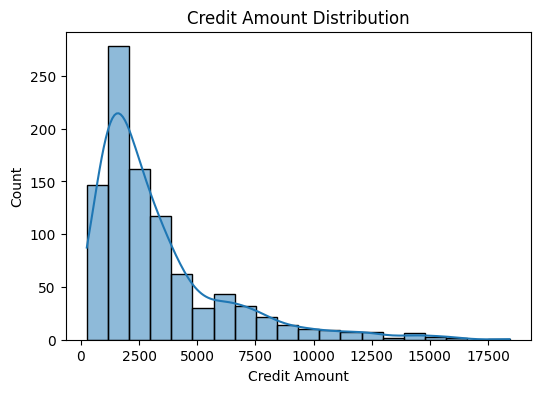

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["Credit amount"], bins=20, kde=True)
plt.title("Credit Amount Distribution")
plt.xlabel("Credit Amount")
plt.ylabel("Count")
plt.show()

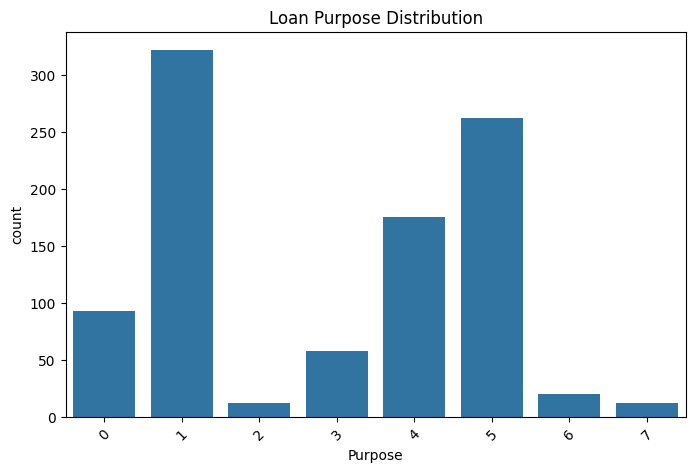

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x="Purpose", data=df)
plt.xticks(rotation=45)
plt.title("Loan Purpose Distribution")
plt.show()

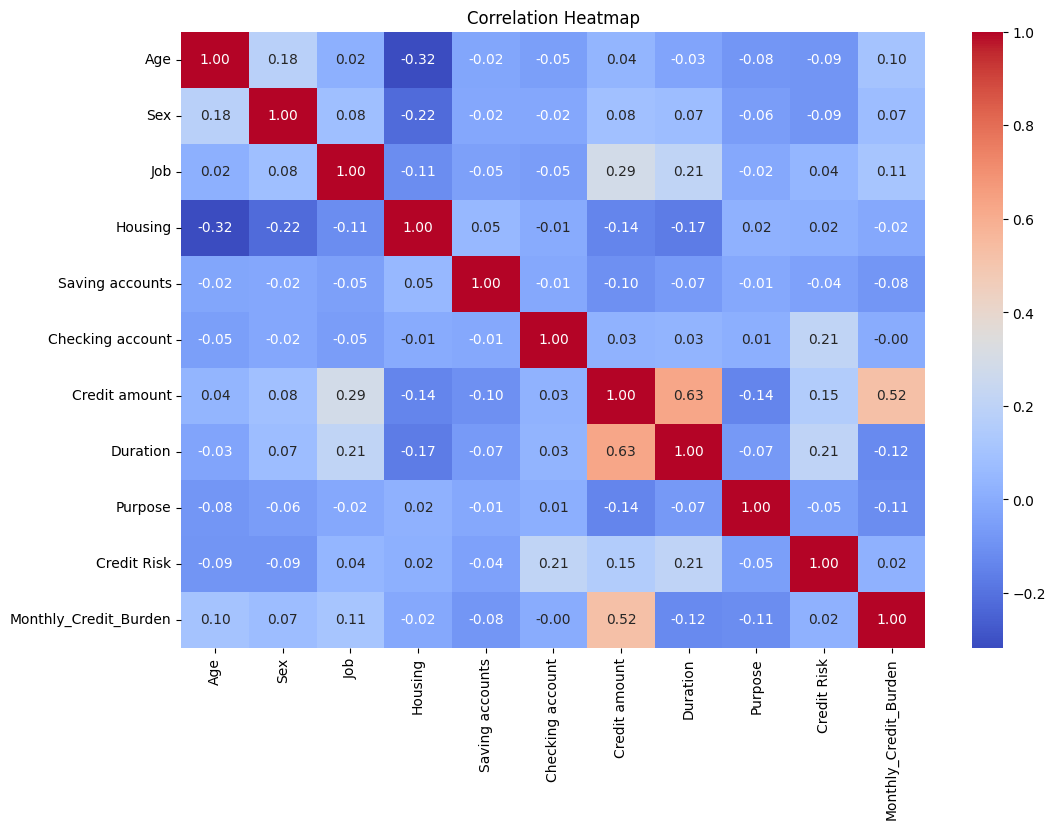

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X = df.drop("Credit Risk", axis=1)
y = df["Credit Risk"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (954, 10)
Target Shape: (954,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.685864
1,Decision Tree,0.628272
2,Random Forest,0.738220


In [ ]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_lr),
        accuracy_score(y_test, pred_dt),
        accuracy_score(y_test, pred_rf)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.685864
1,Decision Tree,0.628272
2,Random Forest,0.738220


ROC-AUC Score : 0.7505


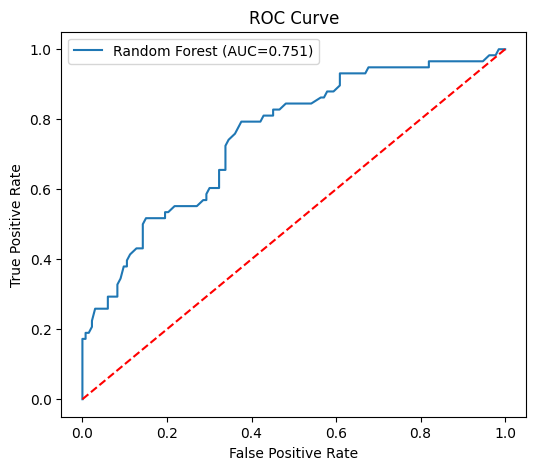

In [ ]:
# Convert labels (1=Good, 2=Bad) to binary (0,1)
y_test_binary = y_test.replace({1:0, 2:1})

# Probability predictions
y_prob = rf.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test_binary, y_prob)

print("ROC-AUC Score :", round(auc,4))

fpr, tpr, _ = roc_curve(y_test_binary, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

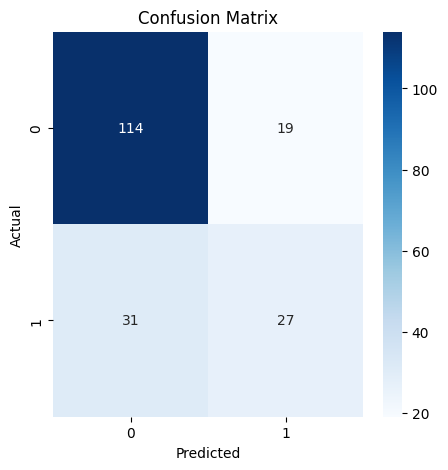

In [ ]:
cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(5,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           1       0.79      0.86      0.82       133
           2       0.59      0.47      0.52        58

    accuracy                           0.74       191
   macro avg       0.69      0.66      0.67       191
weighted avg       0.73      0.74      0.73       191



In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
9,Monthly_Credit_Burden,0.202035
6,Credit amount,0.196517
0,Age,0.135102
5,Checking account,0.131511
7,Duration,0.110065
8,Purpose,0.066379
4,Saving accounts,0.054526
2,Job,0.041599
3,Housing,0.035743
1,Sex,0.026522


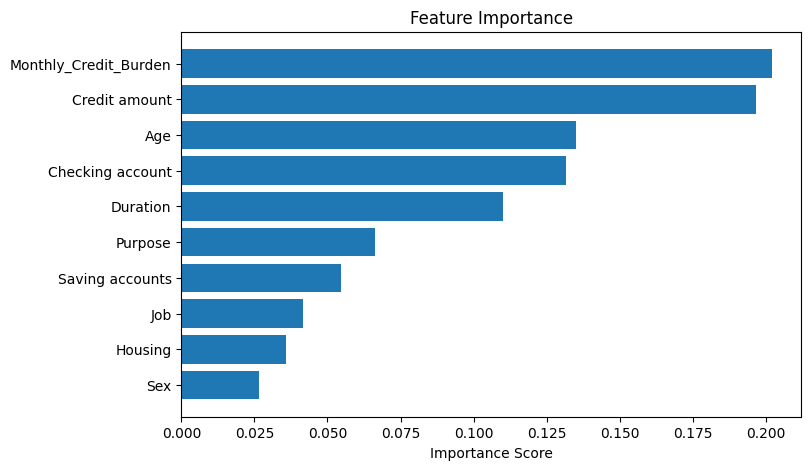

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Feature Importance")
plt.xlabel("Importance Score")

plt.show()

In [ ]:
age = int(input("Enter Age: "))
sex = int(input("Enter Sex (0=Female,1=Male): "))
job = int(input("Enter Job (0-3): "))
housing = int(input("Enter Housing (0-2): "))
saving = int(input("Enter Saving Account (0-4): "))
checking = int(input("Enter Checking Account (0-3): "))
credit = float(input("Enter Credit Amount: "))
duration = int(input("Enter Duration (months): "))
purpose = int(input("Enter Purpose (0-7): "))

monthly_credit_burden = credit / duration

sample = pd.DataFrame([[
    age,
    sex,
    job,
    housing,
    saving,
    checking,
    credit,
    duration,
    purpose,
    monthly_credit_burden
]], columns=X.columns)

prediction = rf.predict(sample)

if prediction[0] == 1:
    print("\n Good Credit Risk")
    print("Loan Recommendation: APPROVED")
else:
    print("\n Bad Credit Risk")
    print("Loan Recommendation: REJECTED")

Enter Age: 55
Enter Sex (0=Female,1=Male): 1
Enter Job (0-3): 1
Enter Housing (0-2): 1
Enter Saving Account (0-4): 1
Enter Checking Account (0-3): 1
Enter Credit Amount: 10000
Enter Duration (months): 24
Enter Purpose (0-7): 1

 Good Credit Risk
Loan Recommendation: APPROVED


In [ ]:
joblib.dump(rf, "credit_scoring_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print(best_model)

Model       Random Forest
Accuracy          0.73822
Name: 2, dtype: object


In [ ]:
print("="*50)
print("     CREDIT SCORING MODEL")
print("="*50)
print("Best Model :", best_model["Model"])
print("Accuracy :", round(best_model["Accuracy"],4))
print("ROC-AUC :", round(auc,4))
print("\nProject Completed Successfully!")
print("="*50)

     CREDIT SCORING MODEL
Best Model : Random Forest
Accuracy : 0.7382
ROC-AUC : 0.7505

Project Completed Successfully!
